In [1]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from datetime import datetime
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_model import  ARIMA,ARIMAResults
from statsmodels.tsa.ar_model import AR,ARResults
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv("vaccineData.csv",index_col='date',parse_dates=['date'])
df.head()

,vaccinations
date,
2021-03-10,1175187
2021-03-11,408379
2021-03-12,1817351
2021-03-13,1381753
2021-03-14,153934


In [3]:
df.isnull().sum()


vaccinations    0
dtype: int64

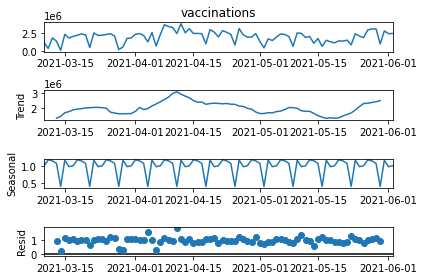

In [4]:
mul = seasonal_decompose(df['vaccinations'],model='multiplicative')
mul.plot();

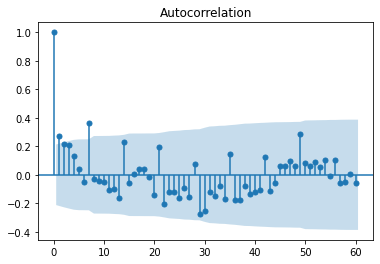

In [5]:
from statsmodels.tsa.stattools import acf,pacf
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
plot_acf(df['vaccinations'].tolist(),lags=60)

plt.show()

In [6]:
dftest = adfuller(df['vaccinations'],autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Stat','p-value','#LAGS','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput["CV (%s)"%key]= value
print(dfoutput)

Test Stat                 -2.228091
p-value                    0.196208
#LAGS                      7.000000
Number of Observations    77.000000
CV (1%)                   -3.518281
CV (5%)                   -2.899878
CV (10%)                  -2.587223
dtype: float64


In [7]:

arima_model =  auto_arima(df,start_p=0, d=1, start_q=0, 
                          max_p=5, max_d=5, max_q=5, start_P=0, 
                          D=1, start_Q=0, max_P=5, max_D=5,
                          max_Q=5, m=7, seasonal=True, 
                          error_action='warn',trace = True,
                          supress_warnings=True,stepwise = True )


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=2308.585, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=2291.122, Time=0.04 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=2272.075, Time=0.05 sec
 ARIMA(0,1,1)(0,1,0)[7]             : AIC=2297.607, Time=0.01 sec
 ARIMA(0,1,1)(1,1,1)[7]             : AIC=2274.056, Time=0.06 sec
 ARIMA(0,1,1)(0,1,2)[7]             : AIC=2274.043, Time=0.12 sec
 ARIMA(0,1,1)(1,1,0)[7]             : AIC=2287.658, Time=0.03 sec
 ARIMA(0,1,1)(1,1,2)[7]             : AIC=2275.545, Time=0.21 sec
 ARIMA(0,1,0)(0,1,1)[7]             : AIC=inf, Time=0.04 sec
 ARIMA(1,1,1)(0,1,1)[7]             : AIC=2273.587, Time=0.07 sec
 ARIMA(0,1,2)(0,1,1)[7]             : AIC=2275.169, Time=0.06 sec
 ARIMA(1,1,0)(0,1,1)[7]             : AIC=2274.882, Time=0.05 sec
 ARIMA(1,1,2)(0,1,1)[7]             : AIC=2276.974, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[7] intercept   : AIC=2273.876, Time=0.06 sec

Best model:  ARIMA(0,1,1)(0,1,1)[7]  

array([[<AxesSubplot:title={'center':'0'}>]], dtype=object)

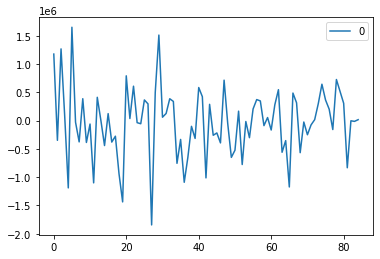

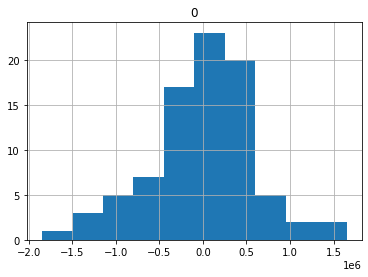

In [8]:
pd.DataFrame(arima_model.resid()).plot()
pd.DataFrame(arima_model.resid()).hist()

In [9]:
prediction = pd.DataFrame(arima_model.predict(n_periods = 15))
prediction.columns = ['predicted_Vaccinations']
prediction

,predicted_Vaccinations
0,2.790673e+06
1,2.760313e+06
2,2.675328e+06
3,1.445522e+06
4,2.914256e+06
5,2.553341e+06
6,2.558927e+06
7,2.943304e+06
8,2.912944e+06
9,2.827959e+06


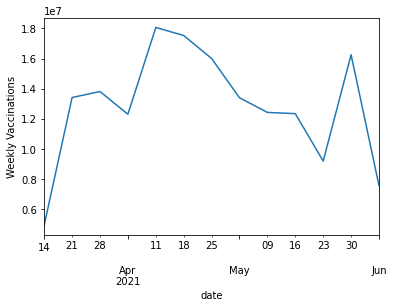

In [10]:
weekly = df.resample('W').sum()
weekly['vaccinations'].plot(style=['-'])
plt.ylabel('Weekly Vaccinations')
plt.show();


In [11]:
arima_model =  auto_arima(weekly,start_p=0, d=1, start_q=0, 
                          max_p=5, max_d=5, max_q=5, start_P=0, 
                          D=1, start_Q=0, max_P=5, max_D=5,
                          max_Q=5, m=7, seasonal=True, 
                          error_action='warn',trace = True,
                          supress_warnings=True,stepwise = True )

                        

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=174.909, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=inf, Time=0.05 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=0.10 sec
 ARIMA(0,1,0)(1,1,0)[7]             : AIC=172.426, Time=0.01 sec
 ARIMA(0,1,0)(2,1,0)[7]             : AIC=174.239, Time=0.07 sec
 ARIMA(0,1,0)(1,1,1)[7]             : AIC=inf, Time=0.03 sec
 ARIMA(0,1,0)(0,1,1)[7]             : AIC=inf, Time=0.02 sec
 ARIMA(0,1,0)(2,1,1)[7]             : AIC=176.239, Time=0.04 sec
 ARIMA(0,1,1)(1,1,0)[7]             : AIC=inf, Time=0.05 sec
 ARIMA(1,1,1)(1,1,0)[7]             : AIC=13858365139598432.000, Time=0.03 sec
 ARIMA(0,1,0)(1,1,0)[7] intercept   : AIC=172.742, Time=0.01 sec

Best model:  ARIMA(0,1,0)(1,1,0)[7]          
Total fit time: 0.424 seconds


In [12]:
train = weekly.iloc[:int(len(weekly.index)*0.85)]
test = weekly.iloc[int(len(weekly.index)*0.85):]
arima_model =  auto_arima(train,start_p=0, d=1, start_q=0, 
                          max_p=5, max_d=5, max_q=5, start_P=0, 
                          D=1, start_Q=0, max_P=5, max_D=5,
                          max_Q=5, m=7, seasonal=True, 
                          error_action='warn',trace = True,
                          supress_warnings=True,stepwise = True )

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=107.784, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=102.349, Time=0.04 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=102.088, Time=0.02 sec
 ARIMA(0,1,1)(0,1,0)[7]             : AIC=100.411, Time=0.01 sec
 ARIMA(0,1,1)(1,1,0)[7]             : AIC=102.074, Time=0.03 sec
 ARIMA(0,1,1)(1,1,1)[7]             : AIC=104.074, Time=0.04 sec
 ARIMA(1,1,1)(0,1,0)[7]             : AIC=102.361, Time=0.02 sec
 ARIMA(0,1,2)(0,1,0)[7]             : AIC=101.778, Time=0.02 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=133.146, Time=0.01 sec
 ARIMA(1,1,2)(0,1,0)[7]             : AIC=inf, Time=0.05 sec
 ARIMA(0,1,1)(0,1,0)[7] intercept   : AIC=102.411, Time=0.01 sec

Best model:  ARIMA(0,1,1)(0,1,0)[7]          
Total fit time: 0.271 seconds


In [13]:
prediction = pd.DataFrame(arima_model.predict(n_periods = len(test.index)),index=test.index)
prediction.columns = ['predicted_vaccinations']
prediction

,predicted_vaccinations
date,
2021-05-30,1.312627e+07
2021-06-06,1.259127e+07


In [14]:
print(np.sqrt(np.mean((test['vaccinations'] - prediction['predicted_vaccinations'])**2)))

4189051.501385822
